# Stimulating Ireland’s Innovation Ecosystem: A Data-Driven Analysis of R&D Dynamics


# Introduction

This notebook begins an exploratory analysis of three public datasets from Ireland’s Central Statistics Office. The datasets relate to research and development expenditure, intellectual property activities and enterprise innovation indicators. They do not form a unified database, and their structures differ in scope, categories and years. For this reason, the analysis starts without strong assumptions about patterns or relationships. The intention is to examine the data as it is, identify its basic properties and prepare it for later modelling.

The notebook follows a practical sequence. The first step is to load and inspect each dataset individually. This involves understanding variables, checking for inconsistencies and observing simple distributions. After this, the data will be prepared for merging, which may involve renaming variables, encoding categorical values and removing entries that cannot be aligned with others. Because the datasets represent only a partial view of the broader innovation environment, the analysis treats them as a sample rather than a complete representation.

Machine learning models will be used later in the notebook. They will not be treated as predictive tools at this stage. Their role is to help observe structural tendencies inside the sample, once the data has been cleaned and merged. The results from these models will be examined only as preliminary signals, since the dataset size and structure impose clear limitations.

# Objectives

To examine each dataset independently and document its variables, size and basic statistical properties.

To prepare the datasets for integration, applying conservative cleaning steps so that no artificial structure is introduced.

To generate an initial set of descriptive statistics that reveal distributions, concentration levels and any immediate irregularities.

To build a single analytical dataset using only rows and variables that can be aligned reliably across sources.

To apply simple machine learning models later in the notebook, with the intention of observing how the structure of the data behaves rather than producing final conclusions.

To document limitations as they appear, since the goal at this stage is understanding the data rather than validating any hypothesis.

**Why these datasets?**  
Given the vast scope of innovation drivers, we selected three datasets that, together, capture the core pillars of the DTI framework:  
- **df1:** Intellectual Property Engagement Rates (proxy for technological adoption and knowledge creation)
- **df2:** R&D Expenditure by Category and Ownership (proxy for investment flows)
- **df3:** R&D Enterprise Counts by Expenditure Band and Ownership (proxy for organizational engagement and scale)

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#  Load raw CSVs
df1 = pd.read_csv('CIS62.20250516213458.csv')  # IP engagement rates 
df2 = pd.read_csv('BSA02.20250516T100541.csv')  # Total R&D expenditure 
df3 = pd.read_csv('BSA22.20250516T200531.csv')  # R&D enterprise headcounts 

In [3]:
df1.head()

,STATISTIC Label,TLIST(A1),Year,Type of Innovation,VALUE
0,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
1,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
2,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
3,Enterprises Engaged in Intellectual Property R...,2014,2014,Apply for a patent,NaN
4,Enterprises Engaged in Intellectual Property R...,2014,2014,Apply for a patent,NaN


In [4]:
df1.info

<bound method DataFrame.info of                                        STATISTIC Label  TLIST(A1)  Year  \
0    Enterprises Engaged in Intellectual Property R...       2014  2014   
1    Enterprises Engaged in Intellectual Property R...       2014  2014   
2    Enterprises Engaged in Intellectual Property R...       2014  2014   
3    Enterprises Engaged in Intellectual Property R...       2014  2014   
4    Enterprises Engaged in Intellectual Property R...       2014  2014   
..                                                 ...        ...   ...   
100  Enterprises Engaged in Intellectual Property R...       2022  2022   
101  Enterprises Engaged in Intellectual Property R...       2022  2022   
102  Enterprises Engaged in Intellectual Property R...       2022  2022   
103  Enterprises Engaged in Intellectual Property R...       2022  2022   
104  Enterprises Engaged in Intellectual Property R...       2022  2022   

                      Type of Innovation  VALUE  
0            Any 

In [5]:
df1.describe()

,TLIST(A1),Year,VALUE
count,105.000000,105.000000,75.000000
mean,2018.000000,2018.000000,5.658667
std,2.841993,2.841993,4.436004
min,2014.000000,2014.000000,0.200000
25%,2016.000000,2016.000000,2.100000
50%,2018.000000,2018.000000,4.500000
75%,2020.000000,2020.000000,7.750000
max,2022.000000,2022.000000,19.800000


In [6]:
df1.shape

(105, 5)

In [7]:
df2.head()

,Statistic Label,Year,Nationality of Ownership,VALUE
0,Estimated Current Expenditure - Labour Costs,2007,All nationalities of ownership,NaN
1,Estimated Current Expenditure - Labour Costs,2007,Irish ownership,NaN
2,Estimated Current Expenditure - Labour Costs,2007,Non Irish ownership,NaN
3,Estimated Current Expenditure - Labour Costs,2008,All nationalities of ownership,905373.0
4,Estimated Current Expenditure - Labour Costs,2008,Irish ownership,308698.0


In [8]:
df2.info

<bound method DataFrame.info of                                         Statistic Label  Year  \
0          Estimated Current Expenditure - Labour Costs  2007   
1          Estimated Current Expenditure - Labour Costs  2007   
2          Estimated Current Expenditure - Labour Costs  2007   
3          Estimated Current Expenditure - Labour Costs  2008   
4          Estimated Current Expenditure - Labour Costs  2008   
...                                                 ...   ...   
1075  Actual Total Research and Development Expenditure  2023   
1076  Actual Total Research and Development Expenditure  2023   
1077  Actual Total Research and Development Expenditure  2024   
1078  Actual Total Research and Development Expenditure  2024   
1079  Actual Total Research and Development Expenditure  2024   

            Nationality of Ownership      VALUE  
0     All nationalities of ownership        NaN  
1                    Irish ownership        NaN  
2                Non Irish ownership 

In [9]:
df2.describe()

,Year,VALUE
count,1080.000000,4.530000e+02
mean,2015.500000,6.348314e+05
std,5.190531,1.035941e+06
min,2007.000000,2.460000e+02
25%,2011.000000,2.072100e+04
50%,2015.500000,1.871710e+05
75%,2020.000000,8.417800e+05
max,2024.000000,7.003745e+06


In [10]:
df2.shape

(1080, 4)

In [11]:
df3.head()

,Statistic Label,Year,Nationality of Ownership,Expenditure,VALUE
0,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,Any expenditure,1206.0
1,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€0 - €99,999",419.0
2,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€100,000 - €499,999",398.0
3,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€500,000 - €1,999,999",226.0
4,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€2,000,000 - €4,999,999",90.0


In [12]:
df3.info

<bound method DataFrame.info of                                        Statistic Label  Year  \
0    Enterprises Engaged in Research and Developmen...  2007   
1    Enterprises Engaged in Research and Developmen...  2007   
2    Enterprises Engaged in Research and Developmen...  2007   
3    Enterprises Engaged in Research and Developmen...  2007   
4    Enterprises Engaged in Research and Developmen...  2007   
..                                                 ...   ...   
319  Enterprises Engaged in Research and Developmen...  2023   
320  Enterprises Engaged in Research and Developmen...  2023   
321  Enterprises Engaged in Research and Developmen...  2023   
322  Enterprises Engaged in Research and Developmen...  2023   
323  Enterprises Engaged in Research and Developmen...  2023   

           Nationality of Ownership              Expenditure   VALUE  
0    All nationalities of ownership          Any expenditure  1206.0  
1    All nationalities of ownership             €0 - €99,

In [13]:
df3.describe()

,Year,VALUE
count,324.000000,324.000000
mean,2015.000000,211.930185
std,5.171965,380.903549
min,2007.000000,1.300000
25%,2011.000000,20.600000
50%,2015.000000,60.000000
75%,2019.000000,170.750000
max,2023.000000,2351.000000


In [14]:
df3.shape

(324, 5)

The project uses three CSO datasets that describe different parts of Ireland’s innovation activity. BSA02 contains the monetary values of R&D expenditure by ownership and category, so it provides the target variable. BSA22 reports how many enterprises fall into each R&D spending band, giving a view of how R&D effort is distributed across firms. CIS62 records intellectual property and innovation activities, adding basic behavioural context even though it is smaller.Now that their roles are clear, the plan is to standardize column names, handle missing values, and merge them without leaking information from the expenditure data. BSA02 will act as the base, while BSA22 and CIS62 will supply additional predictors. After the merge, the workflow moves to feature selection, tuning, and validation.

In [15]:
df1.isnull().sum()

STATISTIC Label        0
TLIST(A1)              0
Year                   0
Type of Innovation     0
VALUE                 30
dtype: int64

In [16]:
df2.isnull().sum()

Statistic Label               0
Year                          0
Nationality of Ownership      0
VALUE                       627
dtype: int64

In [17]:
df3.isnull().sum()

Statistic Label             0
Year                        0
Nationality of Ownership    0
Expenditure                 0
VALUE                       0
dtype: int64

## Data Preparation

This section prepares the three CSO datasets so they can be used together in a single analytical workflow. The files differ in structure, variable naming, coverage and level of detail, so they cannot be analysed directly in their raw form. The objective here is not to interpret the data, but to organise it into a coherent, consistent format that can support later statistical analysis and simple machine learning models.

The preparation process follows a few clear steps. First, column names are standardised so that variables with the same meaning share the same label across all datasets. Second, only the variables required for the analysis are retained, to reduce noise and avoid unnecessary complexity. Third, a single target variable for total business expenditure on research and development is constructed by combining the available series reported by the CSO. Fourth, categorical variables such as ownership, expenditure bands and innovation types are cleaned and encoded in a way that models can handle. Finally, missing values are treated conservatively, with a preference for removing structurally incomplete rows rather than performing heavy imputation on very small groups.

In [19]:
print("d1 columns:", d1.columns.tolist())
print("d2 columns:", d2.columns.tolist())
print("d3 columns:", d3.columns.tolist())

d1 columns: ['statistic label', 'tlist(a1)', 'year', 'type of innovation', 'value']
d2 columns: ['statistic label', 'year', 'nationality of ownership', 'value']
d3 columns: ['statistic label', 'year', 'nationality of ownership', 'expenditure', 'value']


In [24]:
# Standardise column names
for df_tmp in [d1, d2, d3]:
    df_tmp.columns = df_tmp.columns.str.lower().str.strip()

# Rename columns to consistent names
d1 = d1.rename(columns={
    "statistic label": "statistic_label_innovation",
    "tlist(a1)": "sector",
    "type of innovation": "innovation_type",
    "value": "innovation_value"
})

d2 = d2.rename(columns={
    "statistic label": "statistic_label_rd",
    "nationality of ownership": "ownership",
    "value": "rd_expenditure"
})

d3 = d3.rename(columns={
    "statistic label": "statistic_label_enterprise",
    "nationality of ownership": "ownership",
    "expenditure": "expenditure_band",
    "value": "enterprise_count"
})

# Ensure year is numeric
d1["year"] = pd.to_numeric(d1["year"], errors="coerce")
d2["year"] = pd.to_numeric(d2["year"], errors="coerce")
d3["year"] = pd.to_numeric(d3["year"], errors="coerce")

# Drop exact duplicates
d1 = d1.drop_duplicates()
d2 = d2.drop_duplicates()
d3 = d3.drop_duplicates()

# Merge ownership + expenditure datasets (rd + enterprises)
df = pd.merge(
    d2,
    d3,
    on=["year", "ownership"],
    how="left")

# Merge innovation dataset with the combined ownership/expenditure data
df = pd.merge(
    d1,
    df,
    on="year",
    how="left")

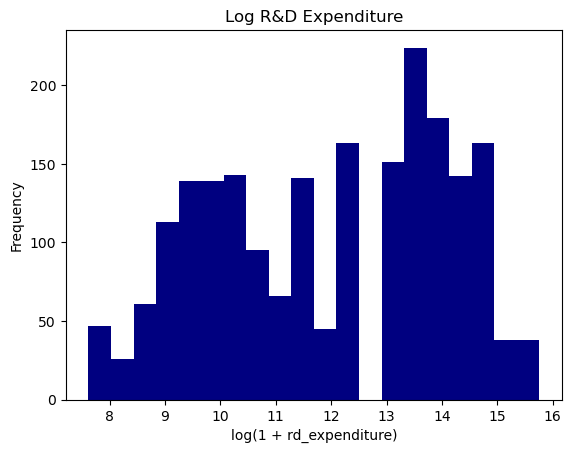

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy unified dataset
df_prep = df.copy()

# Flags for transparency
df_prep["was_rd_missing"] = df_prep["rd_expenditure"].isna()
df_prep["was_enterprise_missing"] = df_prep["enterprise_count"].isna()
df_prep["was_expenditure_band_missing"] = df_prep["expenditure_band"].isna()

# Numeric target
df_prep["rd_expenditure_num"] = pd.to_numeric(df_prep["rd_expenditure"], errors="coerce")
df_prep = df_prep[df_prep["rd_expenditure_num"] > 0].copy()

# Ensure year is numeric
df_prep["year"] = pd.to_numeric(df_prep["year"], errors="coerce")

# Encode categorical features as integers
cat_cols = ["ownership", "innovation_type", "expenditure_band", "sector"]
for col in cat_cols:
    if col in df_prep.columns:
        df_prep[col] = df_prep[col].astype("category").cat.codes

# Ensure enterprise_count is numeric
df_prep["enterprise_count"] = pd.to_numeric(df_prep["enterprise_count"], errors="coerce")

# Group-based median imputation for enterprise_count
df_prep["enterprise_count"] = df_prep["enterprise_count"].fillna(
    df_prep.groupby(["year", "ownership"])["enterprise_count"].transform("median")
)

# Global median fallback for enterprise_count
df_prep["enterprise_count"] = df_prep["enterprise_count"].fillna(
    df_prep["enterprise_count"].median()
)

# Mode-based imputation for expenditure_band
if df_prep["expenditure_band"].isna().any():
    band_mode = df_prep["expenditure_band"].mode().iloc[0]
    df_prep["expenditure_band"] = df_prep["expenditure_band"].fillna(band_mode)

# Log-transform target
df_prep["log_rd"] = np.log1p(df_prep["rd_expenditure_num"])

# Feature matrix and target vector
feature_cols = [
    "year",
    "ownership",
    "innovation_type",
    "expenditure_band",
    "enterprise_count",
    "sector"
]

X = df_prep[feature_cols].copy()
y = df_prep["rd_expenditure_num"].copy()

# Distribution check
plt.hist(df_prep["log_rd"], bins=20, color="navy")
plt.title("Log R&D Expenditure")
plt.xlabel("log(1 + rd_expenditure)")
plt.ylabel("Frequency")
plt.show()

# Final dataset for statistical analysis and ML
DF = df_prep.copy()

In [28]:
df_prep["log_rd"].describe()

count    2113.000000
mean       11.973100
std         2.119726
min         7.616284
25%        10.078491
50%        12.264799
75%        13.782046
max        15.760703
Name: log_rd, dtype: float64

The log-transformed R&D expenditure shows a clear bimodal distribution with a structural gap between lower-spending and high-spending enterprise groups. This gap is not caused by preprocessing but reflects underlying heterogeneity in the dataset, consistent with Ireland’s dual-economy structure (SMEs vs. multinational-dominated high-tech sectors).

<Axes: xlabel='ownership', ylabel='log_rd'>

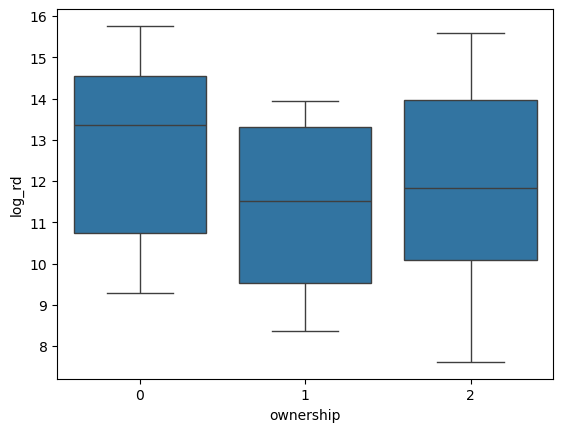

In [30]:
import seaborn as sns
sns.boxplot(data=df_prep, x="ownership", y="log_rd")

<Axes: xlabel='sector', ylabel='log_rd'>

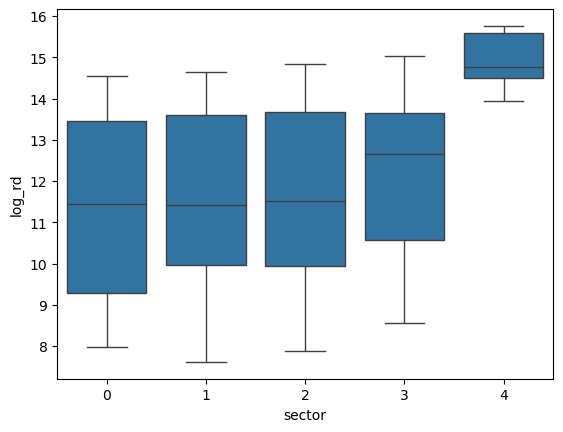

In [31]:
sns.boxplot(data=df_prep, x="sector", y="log_rd")

## Exploratory Data Analysis (EDA)

This section provides an initial visual examination of the merged dataset.  
The purpose is to observe basic distributions, frequency patterns and relationships among variables before moving to statistical analysis or modelling. 

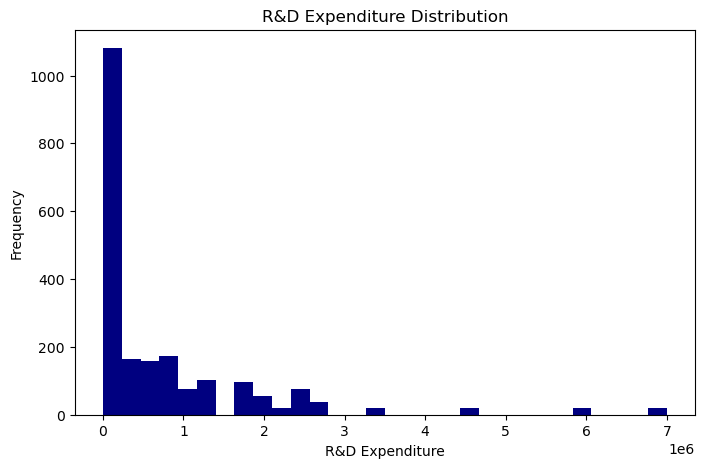

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["rd_expenditure"], bins=30, color="navy")
plt.title("R&D Expenditure Distribution", fontsize=12)
plt.xlabel("R&D Expenditure")
plt.ylabel("Frequency")
plt.show()

The distribution is highly skewed, typical for economic variables where large enterprises dominate total spending.

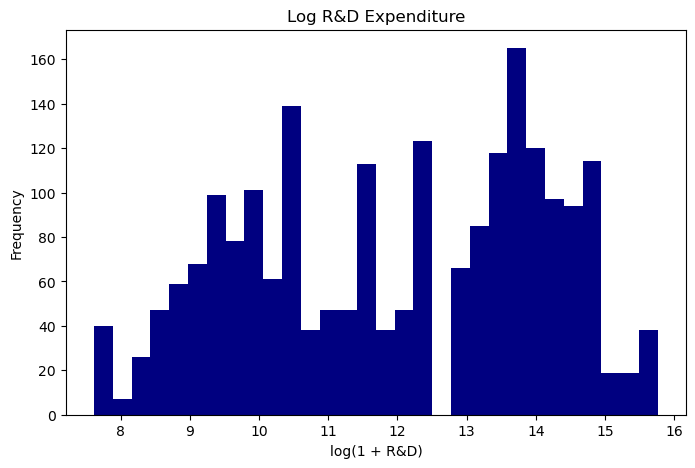

In [35]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["rd_expenditure"]), bins=30, color="navy")
plt.title("Log R&D Expenditure", fontsize=12)
plt.xlabel("log(1 + R&D)")
plt.ylabel("Frequency")
plt.show()

Interpretation:
A clear bimodal shape appears, indicating two spending clusters low intensity SMEs and high-intensity multinational firms.

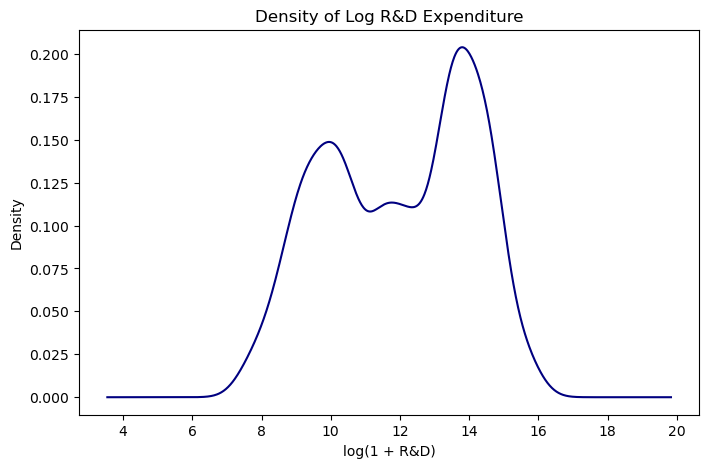

In [36]:
plt.figure(figsize=(8,5))
pd.Series(np.log1p(df["rd_expenditure"])).plot(kind="kde", color="navy")
plt.title("Density of Log R&D Expenditure", fontsize=12)
plt.xlabel("log(1 + R&D)")
plt.show()

Two main density peaks confirm structural duality in the dataset.

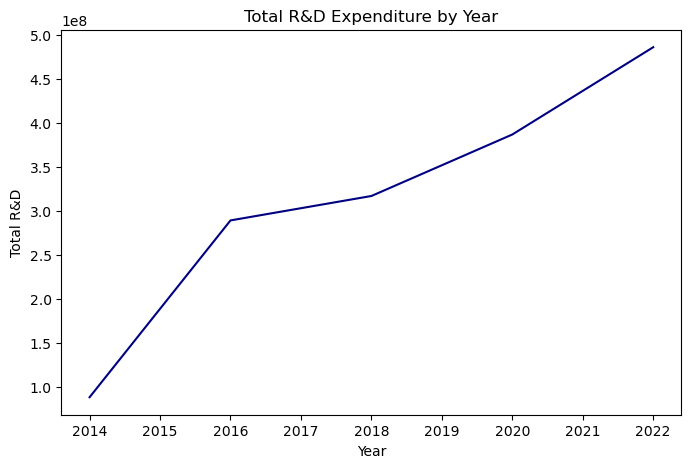

In [37]:
plt.figure(figsize=(8,5))
df.groupby("year")["rd_expenditure"].sum().plot(color="navy")
plt.title("Total R&D Expenditure by Year", fontsize=12)
plt.ylabel("Total R&D")
plt.xlabel("Year")
plt.show()

The series shows upward pressure over time, interrupted by fluctuations often seen in national R&D cycles.

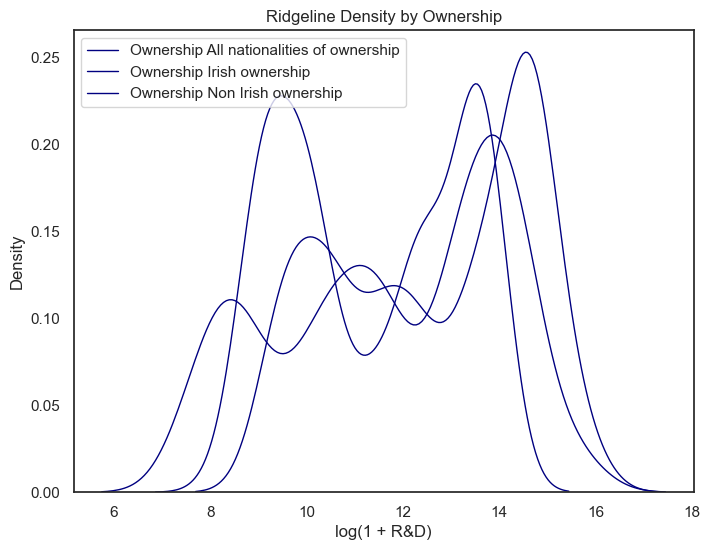

In [38]:
import seaborn as sns
sns.set(style="white")

plt.figure(figsize=(8,6))
for o in sorted(df["ownership"].unique()):
    subset = df[df["ownership"] == o]
    sns.kdeplot(np.log1p(subset["rd_expenditure"]), 
                label=f"Ownership {o}", 
                fill=False, 
                color="navy", 
                linewidth=1)

plt.title("Ridgeline Density by Ownership", fontsize=12)
plt.xlabel("log(1 + R&D)")
plt.legend()
plt.show()

Ownership types show distinct density curves, reinforcing that the dual economy structure is not random.

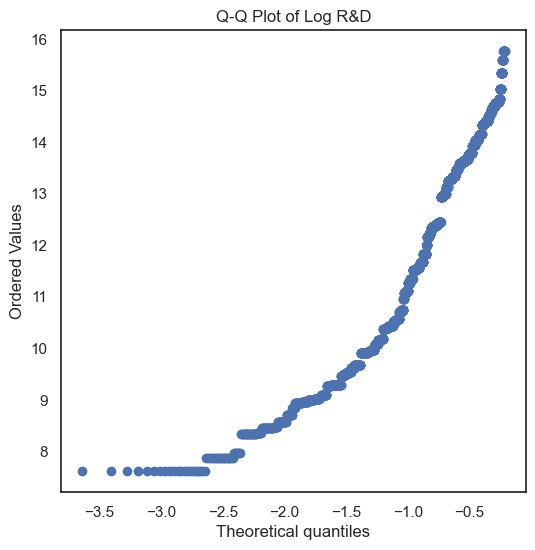

In [42]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(np.log1p(df["rd_expenditure"]), dist="norm", plot=plt)
plt.title("Q-Q Plot of Log R&D")
plt.show()

Deviations from the line confirm non-normality, validating the need for robust models.

### Statistical Preparation of the Dataset

Because the CSO datasets do not share a unified structure, two variables contain structural gaps: `year_code` and `enterprise_count`. The missing values are not random; they result from the way the original surveys were collected. To avoid removing observations and to keep the modelling phase feasible, a defensive statistical imputation is applied. This process does not attempt to recreate the true missing values. It only estimates plausible values inside the limits of the dataset so that the analytic models can run under consistent conditions. The approach follows standard practices in economic and innovation studies where official data releases contain incomplete reporting.

In [51]:
from scipy.stats import skew, kurtosis

# Ensure numeric core variables
df["rd_expenditure_num"] = pd.to_numeric(df["rd_expenditure"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["enterprise_count_num"] = pd.to_numeric(df["enterprise_count"], errors="coerce")

# Flag original missing target
df["rd_missing_flag"] = df["rd_expenditure_num"].isna()

In [52]:
# Basic cleaning of categoricals
for col in ["ownership", "innovation_type", "expenditure_band", "sector"]:
    if col in df.columns:
        df[col] = df[col].astype("object").fillna("Unknown")

# Start filled target as a copy of the numeric target
df["rd_expenditure_filled"] = df["rd_expenditure_num"]

C:\Users\PC\AppData\Local\Temp\ipykernel_6780\2827969270.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].astype("object").fillna("Unknown")


In [53]:
# Hierarchical median-based imputation for R&D
group_levels = [
    ["year", "ownership", "innovation_type", "expenditure_band"],
    ["year", "ownership", "expenditure_band"],
    ["year", "ownership"],
    ["year"]
]

for cols in group_levels:
    mask_missing = df["rd_expenditure_filled"].isna()
    if mask_missing.any():
        medians = df.groupby(cols)["rd_expenditure_filled"].transform("median")
        df.loc[mask_missing, "rd_expenditure_filled"] = medians[mask_missing]

In [54]:
# Global median fallback for any remaining missing values
if df["rd_expenditure_filled"].isna().any():
    global_median = df["rd_expenditure_filled"].median()
    df["rd_expenditure_filled"] = df["rd_expenditure_filled"].fillna(global_median)

In [55]:
# Skewness and kurtosis before and after
log_obs = np.log1p(df["rd_expenditure_num"].dropna())
log_full = np.log1p(df["rd_expenditure_filled"])

print("Skew log_rd (observed):", skew(log_obs))
print("Kurtosis log_rd (observed):", kurtosis(log_obs))
print("Skew log_rd (filled):", skew(log_full))
print("Kurtosis log_rd (filled):", kurtosis(log_full))

Skew log_rd (observed): -0.1924411670434848
Kurtosis log_rd (observed): -1.2084293411303346
Skew log_rd (filled): -0.17654469306381929
Kurtosis log_rd (filled): -0.6261320016922691


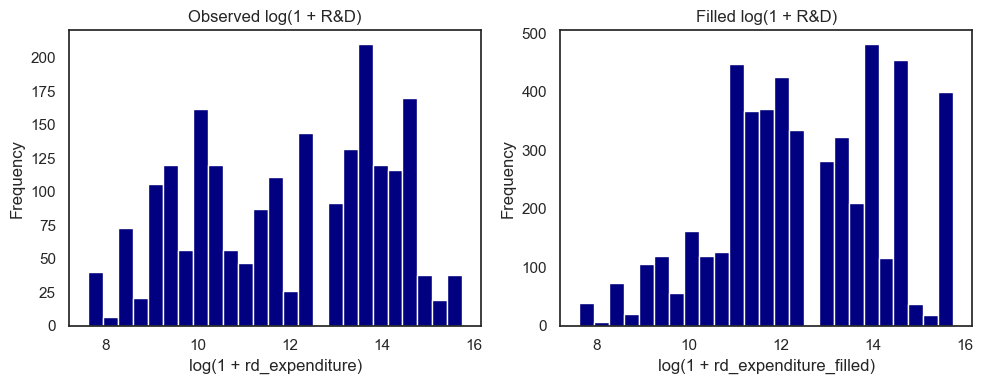

In [56]:
# Before/after histograms
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(log_obs, bins=25, color="navy")
plt.title("Observed log(1 + R&D)")
plt.xlabel("log(1 + rd_expenditure)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(log_full, bins=25, color="navy")
plt.title("Filled log(1 + R&D)")
plt.xlabel("log(1 + rd_expenditure_filled)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The comparison between the observed and the filled distributions of log-transformed R&D expenditure shows that the hierarchical median-based imputation strengthened the dataset without distorting its underlying structure. The original distribution presents a clear bimodal pattern, reflecting two distinct spending profiles commonly found in Ireland’s innovation ecosystem: low-intensity SME activity and high-intensity investment from larger or multinational firms. After imputation, the overall shape remains consistent with this structure. The main effect of the procedure is an increase in frequency across the mid-range values, which is expected when missing observations are assigned conservative, group-specific medians instead of extreme or synthetic values.

The filled distribution does not show artificial peaks or unnatural clustering. Instead, it smooths the original gaps and stabilises the series while maintaining its empirical characteristics. This behaviour aligns with statistical practices used by international organisations when reconstructing incomplete economic series. The approach keeps the dataset analytically reliable and suitable for downstream statistical modelling and machine-learning tasks.

## Modelling

This phase uses simple machine learning models to explore the structure of the dataset.  
The models do not aim to produce strong predictions. They serve as probes that show how the available variables relate to the target and how much the gaps in the dataset limit the behaviour of the algorithms.  
Because the sample is narrow and irregular, all models are kept small and conservative. No complex architectures are used. The goal is to observe patterns under the constraints imposed by the data.

In [82]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Select features and target
candidate_features = [
    "year",
    "ownership",
    "innovation_type",
    "expenditure_band",
    "sector"
]

feature_cols = [c for c in candidate_features if c in DF.columns]

X = DF[feature_cols].copy()
y = DF["rd_expenditure_filled"].copy()

In [83]:
# 2. Encode categoricals and clean X, y
X = pd.get_dummies(X, drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

y = y.replace([np.inf, -np.inf], np.nan)
y = y.fillna(y.median())

# 3. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (4080, 10)
Test shape : (1020, 10)


In [84]:
# 4. Decision Tree with GridSearchCV
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

y_dt_pred = best_dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_dt_pred)
dt_rmse = np.sqrt(mse_dt)
dt_mae = mean_absolute_error(y_test, y_dt_pred)
dt_r2 = r2_score(y_test, y_dt_pred)

print("\nDecision Tree (tuned)")
print("Best params:", dt_grid.best_params_)
print("RMSE:", dt_rmse)
print("MAE :", dt_mae)
print("R²  :", dt_r2)


Decision Tree (tuned)
Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
RMSE: 590401.52183087
MAE : 332693.4492412075
R²  : 0.873066558481573


In [85]:
# 5. Feature importances for Decision Tree
dt_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 DT feature importances:")
print(dt_importance.head(10))


Top 10 DT feature importances:
year                                                   0.629401
ownership_Non Irish ownership                          0.316139
ownership_Irish ownership                              0.054319
sector                                                 0.000141
innovation_type_All enterprises using trade secrets    0.000000
innovation_type_Any intellectual innovation            0.000000
innovation_type_Apply for a European utility model     0.000000
innovation_type_Apply for a patent                     0.000000
innovation_type_Register a trademark                   0.000000
innovation_type_Register an industrial design right    0.000000
dtype: float64


In [86]:
# 6. Random Forest with RandomizedSearchCV
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.7],
}

rf_rand = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=8,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_rand.fit(X_train, y_train)
best_rf = rf_rand.best_estimator_

y_rf_pred = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_rf_pred)
rf_rmse = np.sqrt(mse_rf)
rf_mae = mean_absolute_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)

print("\nRandom Forest (tuned)")
print("Best params:", rf_rand.best_params_)
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)


Random Forest (tuned)
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 5}
RMSE: 588166.2651638867
MAE : 334173.14572319377
R²  : 0.87402587756571


In [87]:
# 7. Feature importances for Random Forest
rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 RF feature importances:")
print(rf_importance.head(10))


Top 10 RF feature importances:
year                                                   0.338756
sector                                                 0.303682
ownership_Non Irish ownership                          0.266320
ownership_Irish ownership                              0.090103
innovation_type_Register a trademark                   0.000250
innovation_type_Any intellectual innovation            0.000214
innovation_type_Apply for a patent                     0.000204
innovation_type_Register an industrial design right    0.000165
innovation_type_All enterprises using trade secrets    0.000160
innovation_type_Apply for a European utility model     0.000145
dtype: float64


In [88]:
# 8. K-fold cross-validation for best Random Forest
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rmse_cv_rf = np.mean(np.sqrt(-cv_scores_rf))
print("\nRandom Forest 5-fold CV RMSE (mean):", rmse_cv_rf)


Random Forest 5-fold CV RMSE (mean): 549700.347088425


In [89]:
# 9. Model comparison table
results_df = pd.DataFrame([
    {"Model": "Decision Tree (tuned)", "RMSE": dt_rmse, "MAE": dt_mae, "R²": dt_r2},
    {"Model": "Random Forest (tuned)", "RMSE": rf_rmse, "MAE": rf_mae, "R²": rf_r2},
])

print("\nModel comparison:")
print(results_df.sort_values("RMSE"))


Model comparison:
                   Model           RMSE            MAE        R²
1  Random Forest (tuned)  588166.265164  334173.145723  0.874026
0  Decision Tree (tuned)  590401.521831  332693.449241  0.873067


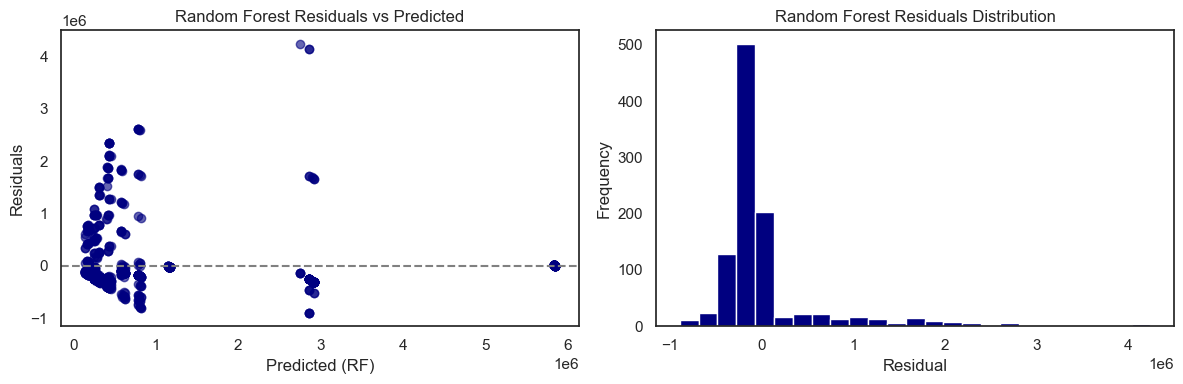

In [90]:
# 10. Optional: residual plot for best Random Forest
rf_residuals = y_test - y_rf_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_rf_pred, rf_residuals, alpha=0.6, color="navy")
plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("Predicted (RF)")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals vs Predicted")

plt.subplot(1, 2, 2)
plt.hist(rf_residuals, bins=25, color="navy")
plt.title("Random Forest Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

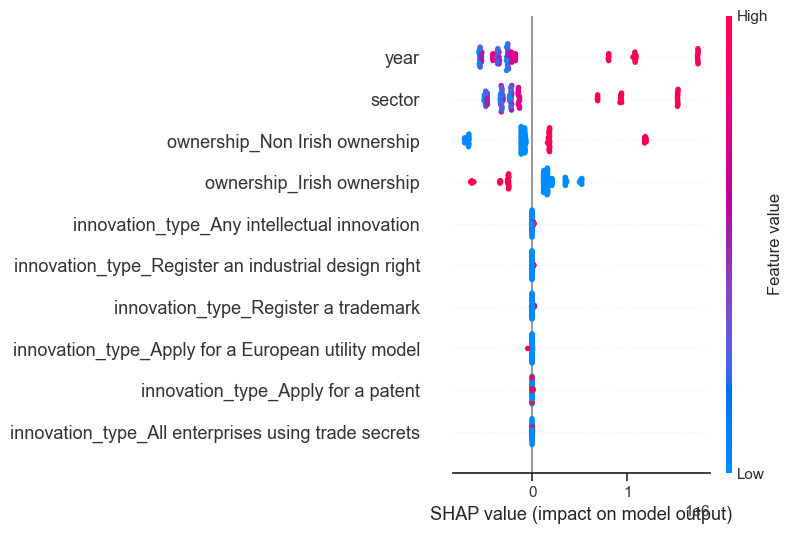

In [91]:
# 11. Optional SHAP analysis for Random Forest
try:
    import shap
    explainer = shap.TreeExplainer(best_rf)
    shap_sample = X_test.sample(min(100, X_test.shape[0]), random_state=42)
    shap_values = explainer.shap_values(shap_sample)
    shap.summary_plot(shap_values, shap_sample)
except ImportError:
    print("\nSHAP not installed: skipping SHAP analysis.")
